## Exploratory Data-Analysis of the IBM Dataset.

In [2]:
import pandas as pd

data = pd.read_csv('../datasets/raw/Telco-Customer-Churn.csv')

In [3]:
df = data.copy()
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [6]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


# Target feature : Churn Value

In [7]:
# dropping columns that are either not useful for modeling or leak churn info

drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",     # duplicate of target
    "Churn Score",     # derived from churn
    "Churn Reason"     # only available after churn
]

df.drop(columns=drop_cols, inplace=True)

In [8]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

In [10]:
## cltv (customer lifetime value) is also derived from churn, so we will drop it as well

df.drop(columns=["CLTV"], inplace=True)

In [11]:
# total charges is str, we will convert it to numeric 

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df.isnull().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64

In [12]:
## only 11 nulls in total charges, we will drop those rows

df.dropna(subset=["Total Charges"], inplace=True)

In [13]:
df["Churn Value"].value_counts(normalize=True)

Churn Value
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [14]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

C:\Users\kavis\AppData\Local\Temp\ipykernel_13376\1919383789.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [15]:
num_cols = num_cols.drop("Churn Value")

In [16]:
num_cols

Index(['Tenure Months', 'Monthly Charges', 'Total Charges'], dtype='str')

In [17]:
cat_cols

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')

## Target Feature Analysis

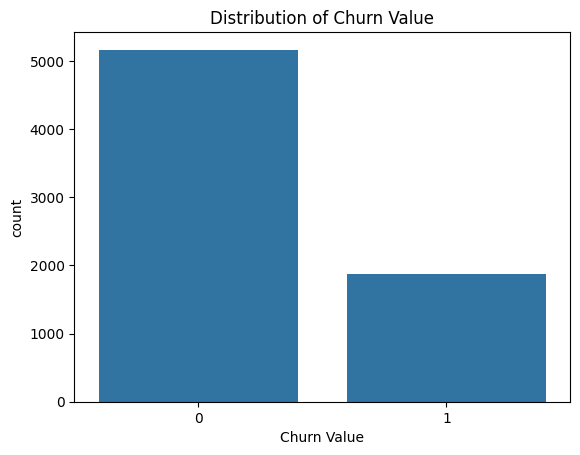

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn Value", data=df)
plt.title("Distribution of Churn Value")
plt.show()

## Numeric Feature Analysis 

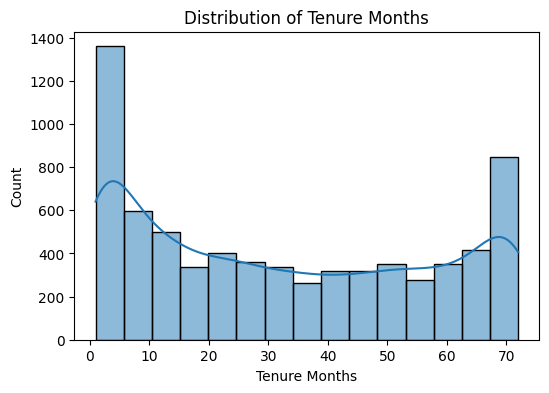

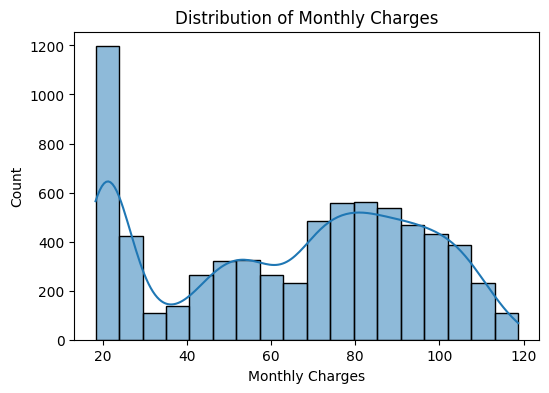

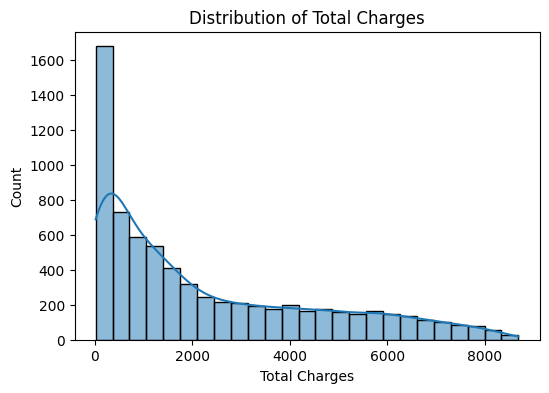

In [19]:
for i in num_cols:

    plt.figure(figsize=(6, 4))
    sns.histplot(df[i], kde=True)
    plt.title(f"Distribution of {i}")
    plt.show()

In [20]:
## observations:
#1. tenure months is right skewed, many customers have been with the company for a short time
#2. monthly charges has a slight bimodal distribution, with many customers having low monthly charges and a smaller peak around 80-90 dollars, which could be due to customers with higher plans or add-ons
#3. total charges is also right skewed and highly correleted with tenure months, which makes sense since total charges is the product of monthly charges and tenure months.
#  The right skewness could be due to a few customers with very high total charges, possibly long-term customers with high monthly charges.

## Target vs Numeric

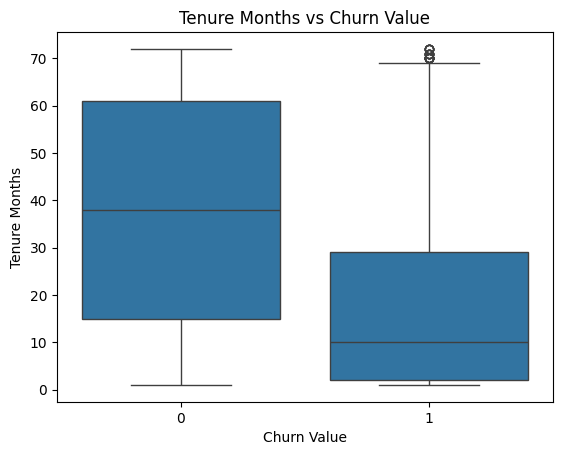

In [21]:
## TENURE VS CHURN

sns.boxplot(x="Churn Value", y="Tenure Months", data=df)
plt.title("Tenure Months vs Churn Value")
plt.show()

In [22]:
## observation: Customers who churn have significantly lower tenure suggesting that customers are more likely to churn in the early months of their subscription

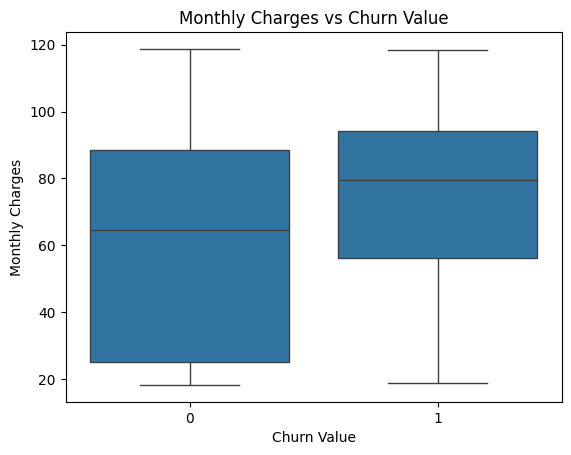

In [23]:
## MONTHLY CHARGES VS CHURN

sns.boxplot(x="Churn Value", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn Value")
plt.show()

In [24]:
# observation: churned customers tend to have higher monthly charges, which could be due to customers with higher plans or add-ons being more likely to churn

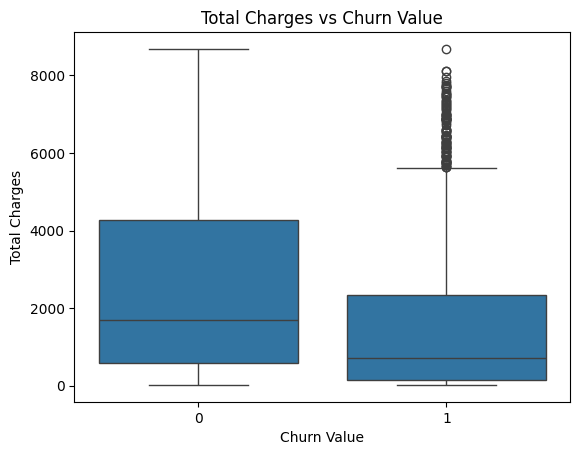

In [25]:
## TOTAL CHARGES VS CHURN

sns.boxplot(x="Churn Value", y="Total Charges", data=df)
plt.title("Total Charges vs Churn Value")
plt.show()

In [26]:
# observation: lower total charges for churners (because low tenure) 

## Categorical Feature Analysis

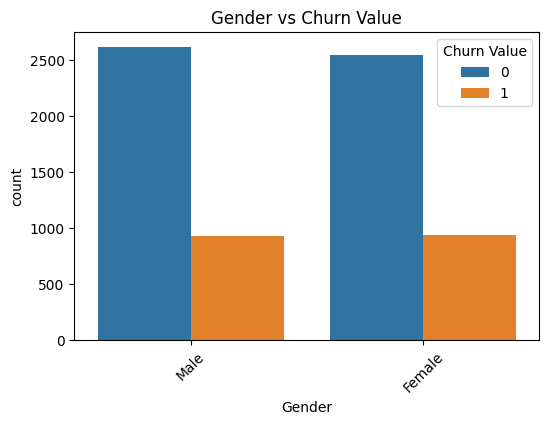

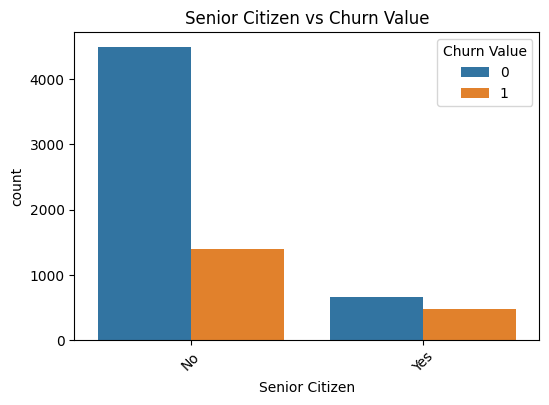

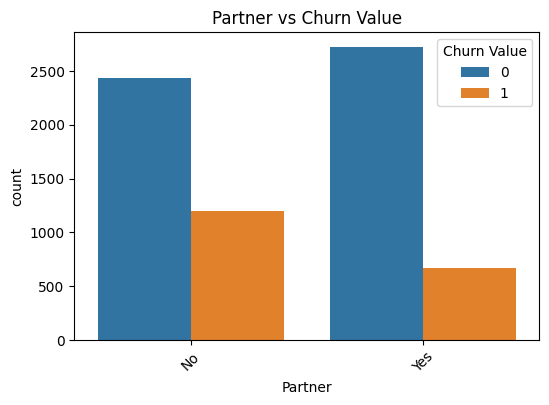

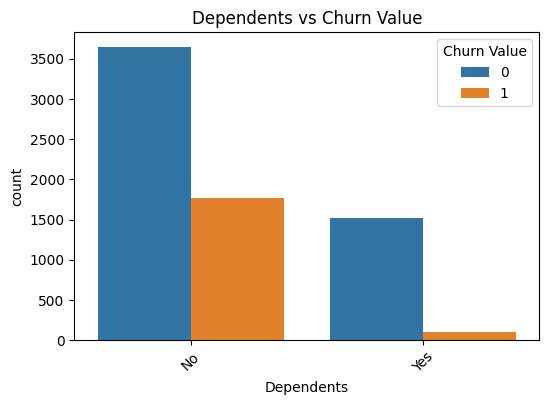

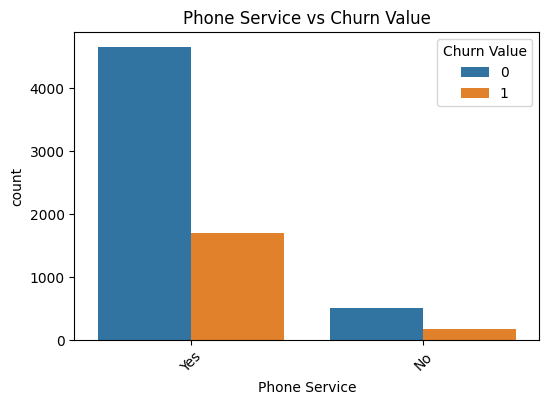

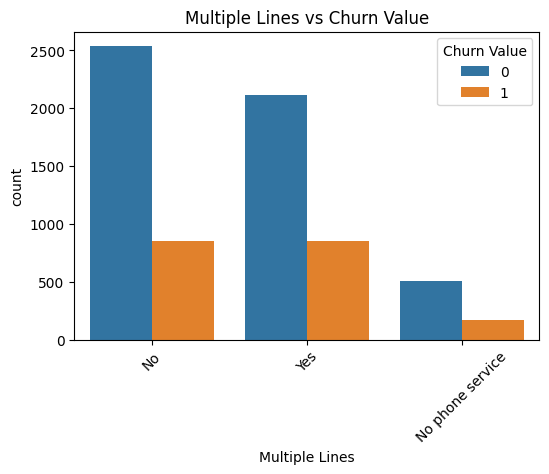

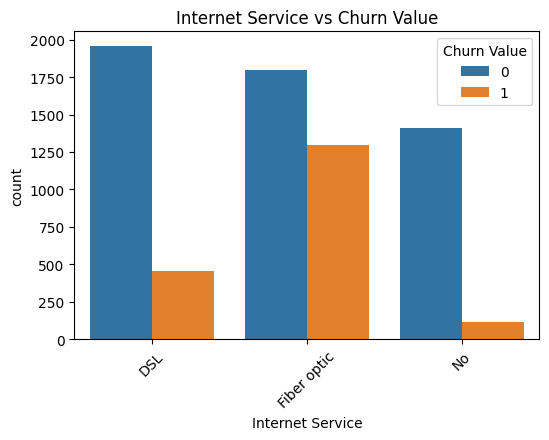

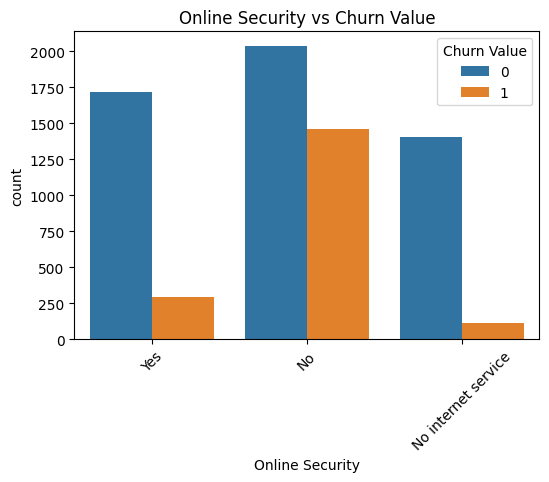

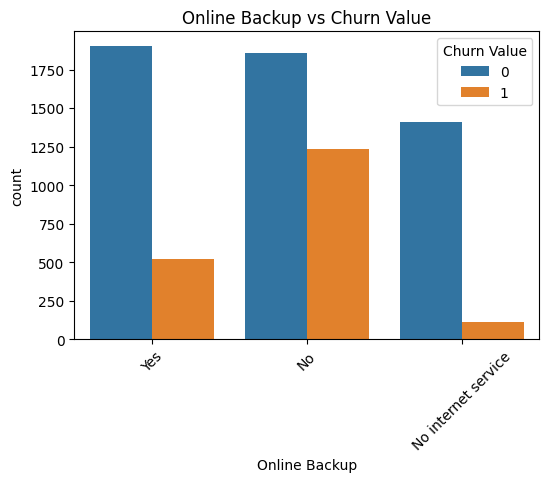

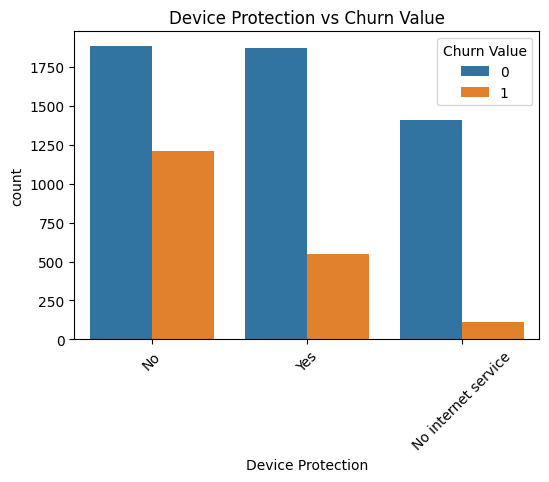

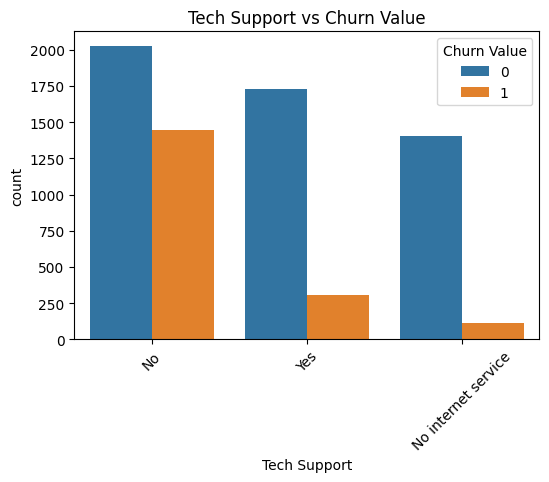

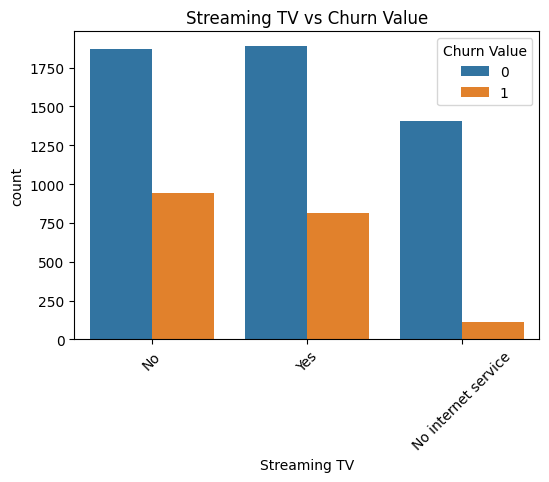

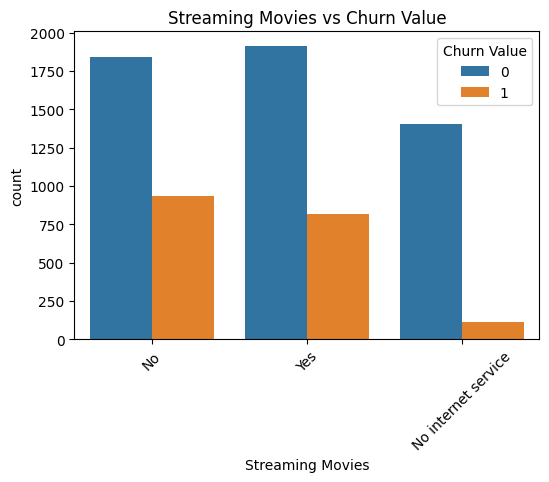

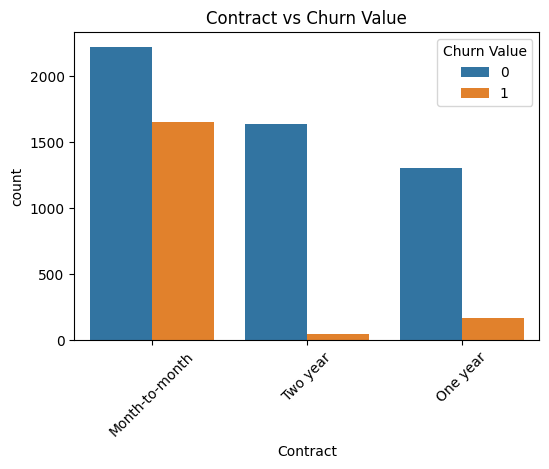

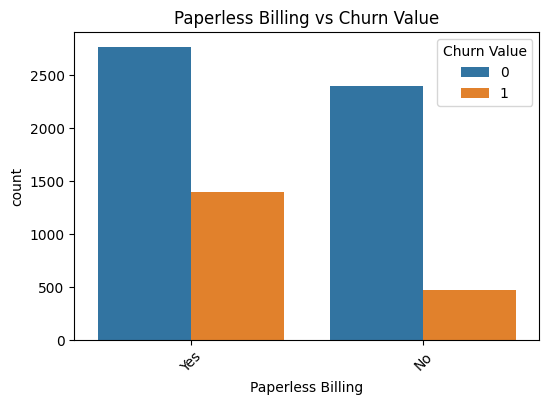

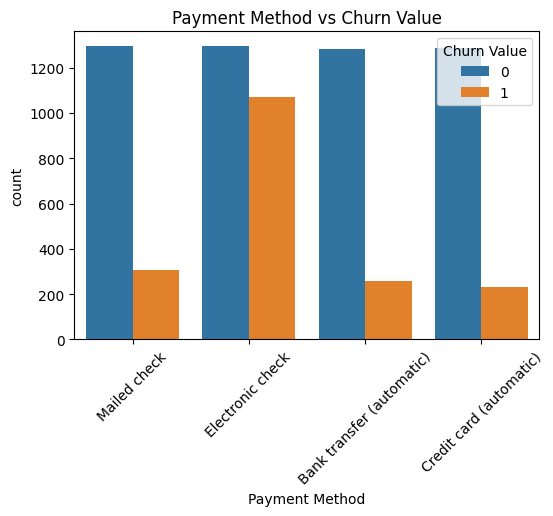

In [27]:
for col in cat_cols:
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="Churn Value", data=df)
    plt.title(f"{col} vs Churn Value")
    plt.xticks(rotation=45)
    plt.legend(title="Churn Value", loc="upper right")
    plt.show()

In [28]:
## observations:

#1. gender does not seem to have a significant impact on churn, as the distribution of churned and non-churned customers is similar

#2. senior citizen customers have a higher churn rate compared to non-senior citizens, which could be due to factors such as lower tech savviness or different service needs

#3. partner customers have a lower churn rate compared to those without partners, which could be due to the added value of having a partner or shared services

#4. dependents customers also have a lower churn rate compared to those without dependents, which could be due to similar reasons as partner customers

#5. phone service customers have a slightly higher churn rate compared to those without phone service, which could be due to the importance of phone service in customer satisfaction and retention

#6. customers with multiple lines have a higher churn rate compared to those without multiple lines, which could be due to the added complexity and cost of managing multiple lines

#7. customers with internet service have a higher churn rate compared to those without internet service, which could be due to the importance of internet service in customer satisfaction and retention

#8. customers with online security have a lower churn rate compared to those without online security, which could be due to the added value of online security in customer satisfaction and retention

#9. customers with online backup have a lower churn rate compared to those without online backup, which could be due to the added value of online backup in customer satisfaction and retention

#10. customers with device protection have a lower churn rate compared to those without device protection, which could be due to the added value of device protection in customer satisfaction and retention

#11. customers with tech support have a lower churn rate compared to those without tech support, which could be due to the added value of tech support in customer satisfaction and retention

#12. customers with streaming TV have a higher churn rate compared to those without streaming TV, which could be due to the added cost and complexity of managing streaming TV services

#13. customers with streaming movies have a higher churn rate compared to those without streaming movies, which could be due to similar reasons as streaming TV customers

#14. customers with contract type of month-to-month have a significantly higher churn rate compared to those with one or two year contracts, 
# which could be due to the lack of commitment and flexibility of month-to-month contracts

#15. customers with paperless billing have a higher churn rate compared to those without paperless billing, which could be due to the added convenience and cost savings of paperless billing

#16. customers with payment method of electronic check have a higher churn rate compared to those with other payment methods, 
# which could be due to the added convenience and cost savings of electronic check payments

## Target vs Categorical

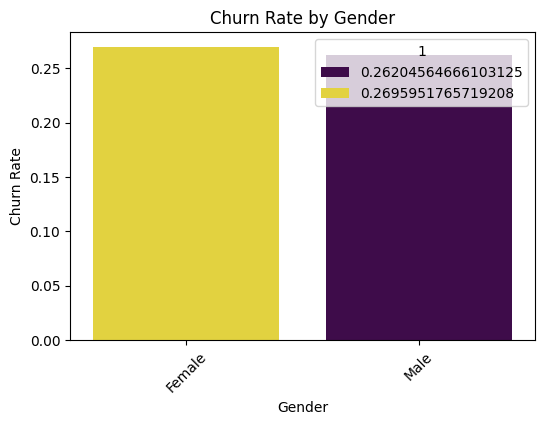

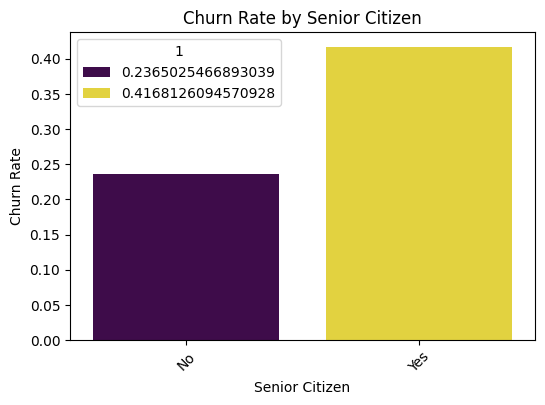

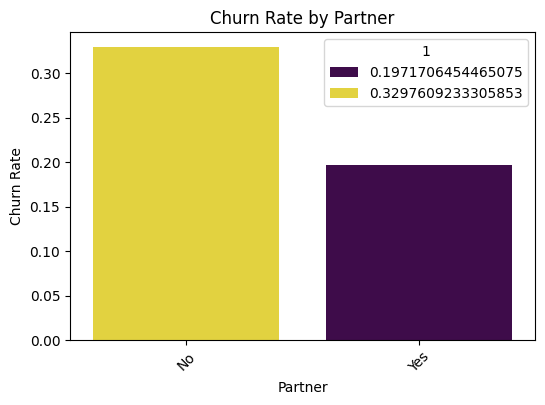

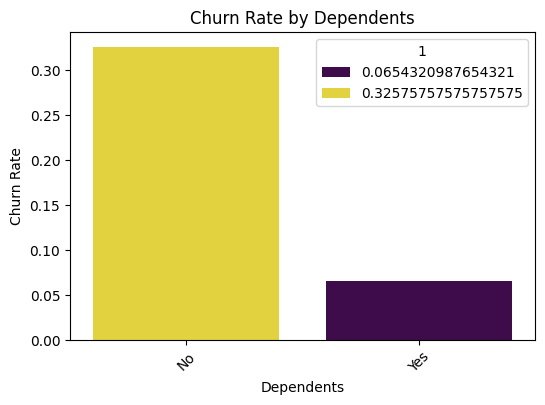

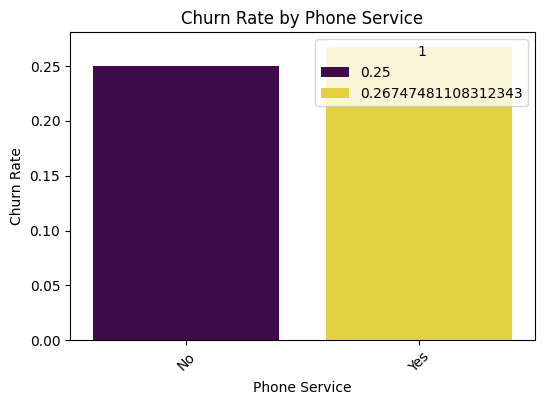

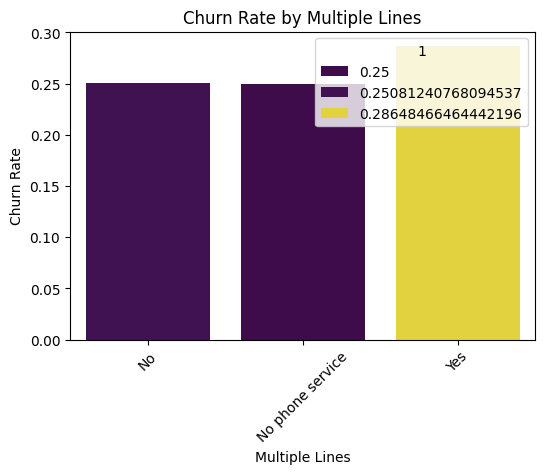

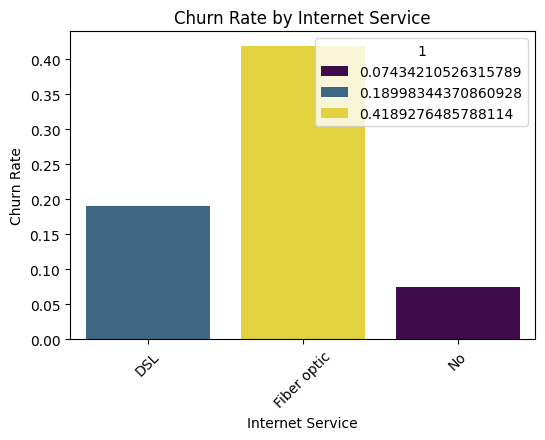

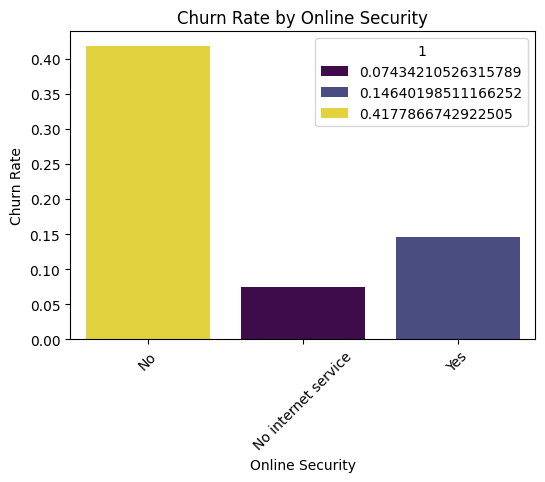

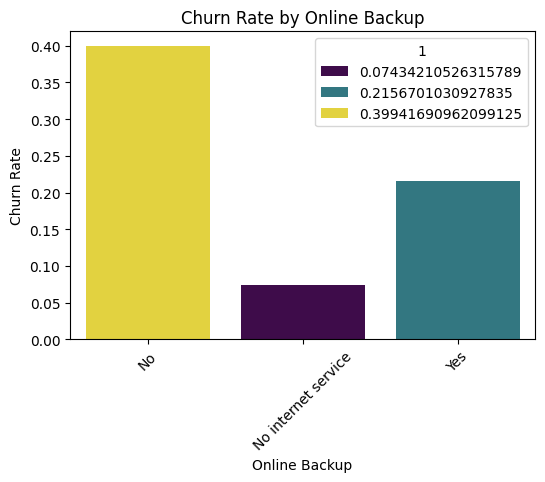

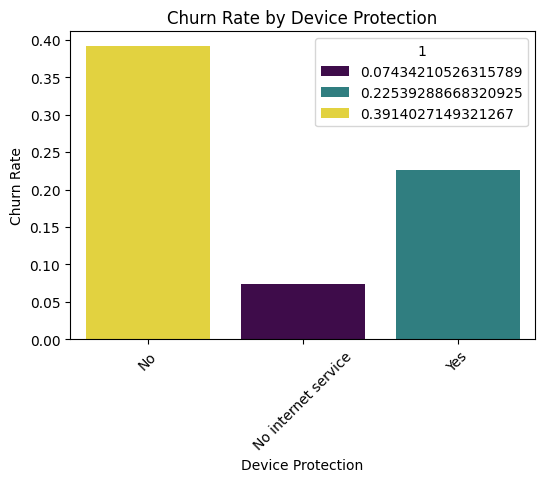

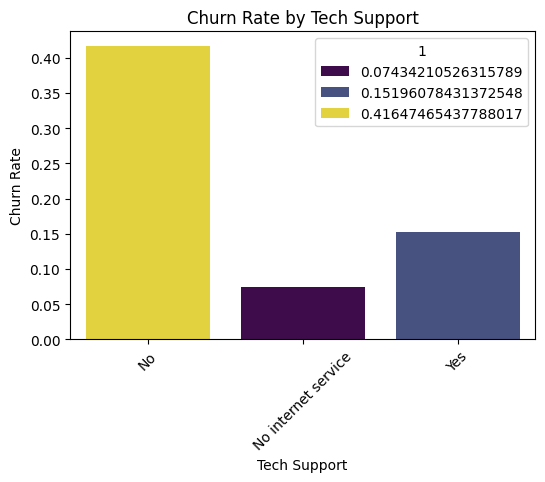

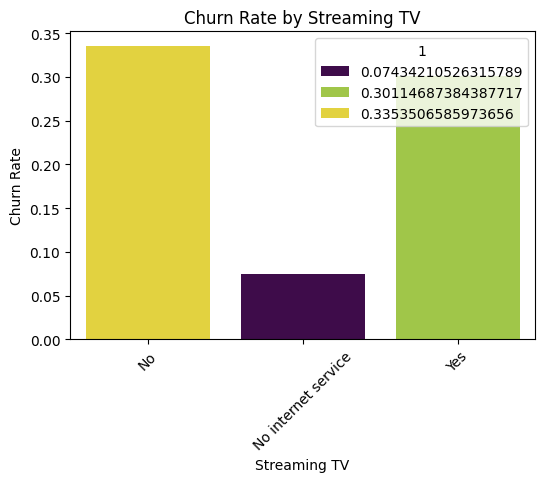

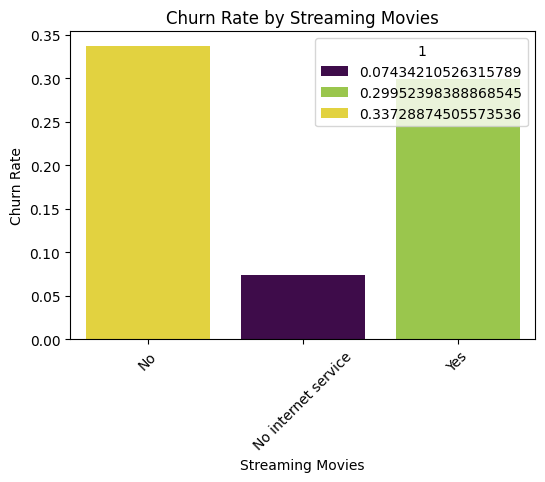

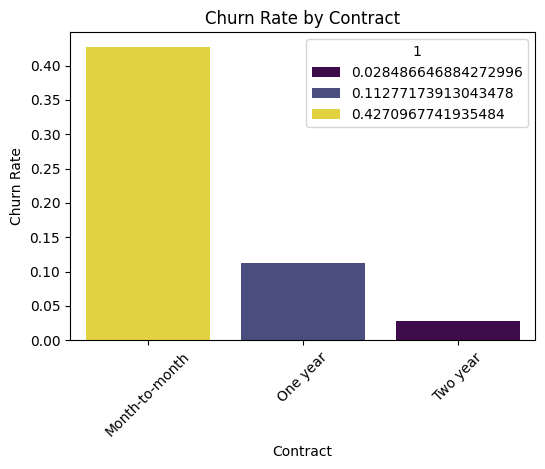

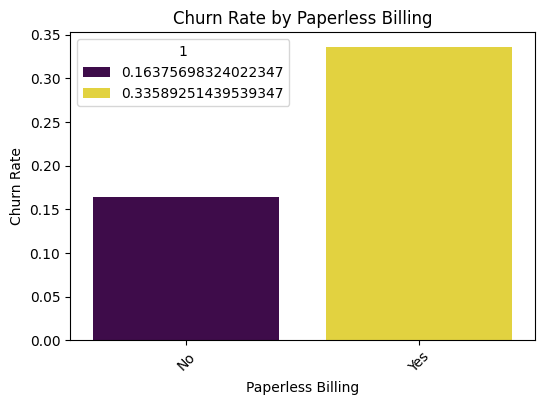

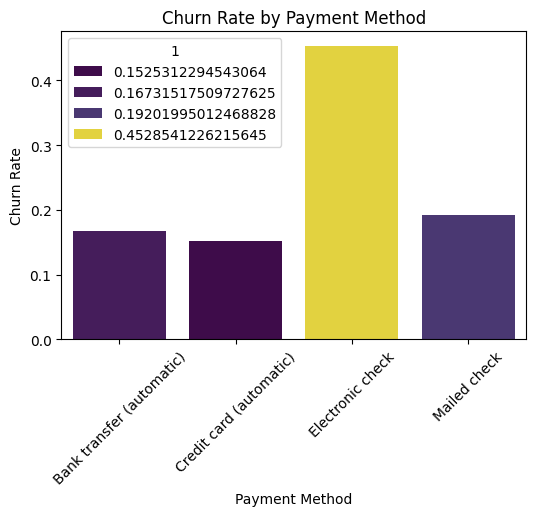

In [29]:
for col in cat_cols:

    churn_rate = pd.crosstab(df[col], df["Churn Value"], normalize="index")

    plt.figure(figsize=(6, 4))
    sns.barplot(x=churn_rate.index, y=churn_rate[1], palette="viridis", hue=churn_rate[1])
    
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)  
    plt.show()


In [30]:
## observations:
#1. contract type of month-to-month has a significantly higher churn rate compared to one or two year contracts, which could be due to the lack of commitment and flexibility of month-to-month contracts
#2. fiber service has a higher churn rate compared to other internet service types, which could be due to factors such as higher cost or technical issues associated with fiber service
#3. payment method of electronic check has a higher churn rate compared to other payment methods, which could be due to the added convenience and cost savings of electronic check payments
#4. online security/tech support: customers without online security/support churn more, which could be due to the added value of online security/support in customer satisfaction and retention

## Correlation Check 

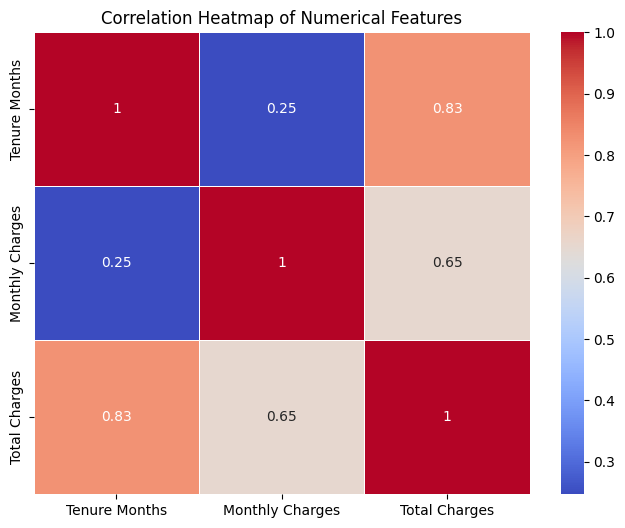

In [31]:
# correlation heatmap for numerical features

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:
# observations
#1. tenure is negatively correlated with churn, which makes sense since customers are more likely to churn in the early months of their subscription
#2. monthly charges is positively correlated with churn, which could be due to customers with higher plans or add-ons being more likely to churn

# Top Churn Drivers:
1. Contract Type (month-to-month = higher churn)
2. Tenure Month (Low tenure = high churn)
2. Internet Service (fiber optic = high churn)
3. Monthly Charges (higher = more churn)
4. Online Security / Tech Support (No = more churn)


# Redundant features:
1. Total Charges: tenure months and total charges are highly correlated, we will drop total charges since it is derived from tenure and monthly charges.
2. Churn Label/Reason/Label: They are all derived from churn value, we will drop them as well.
3. CLTV: It is also derived from churn, we will drop it as well.
4. customer ID, count, country, state, city, zip code, lat long, latitude, longitude are not useful for modeling and may leak information, we will drop them as well.

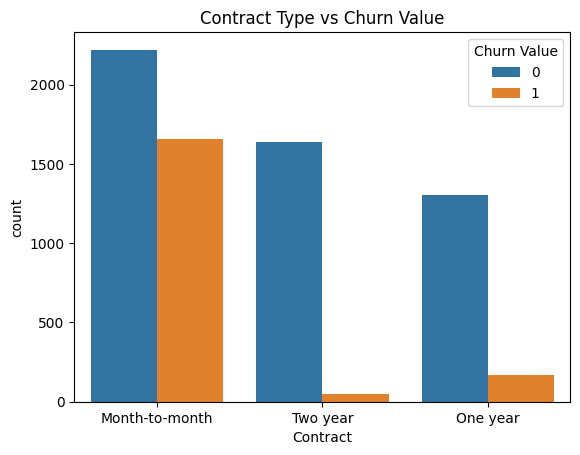

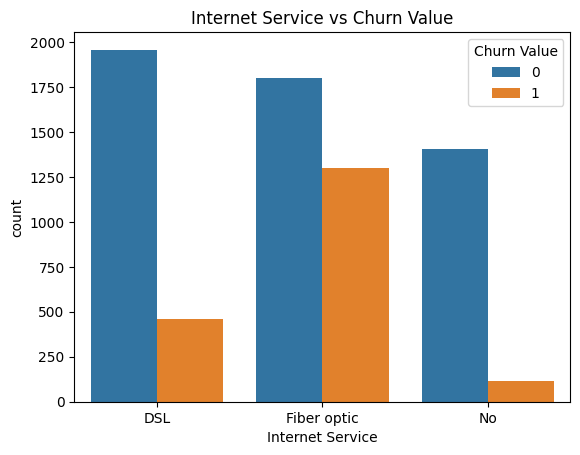

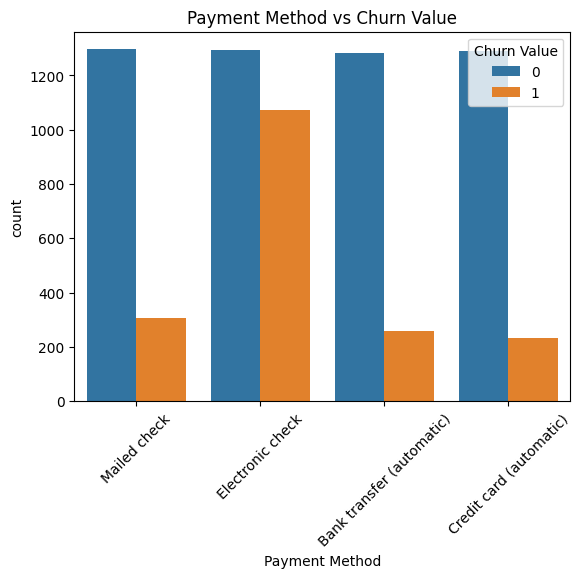

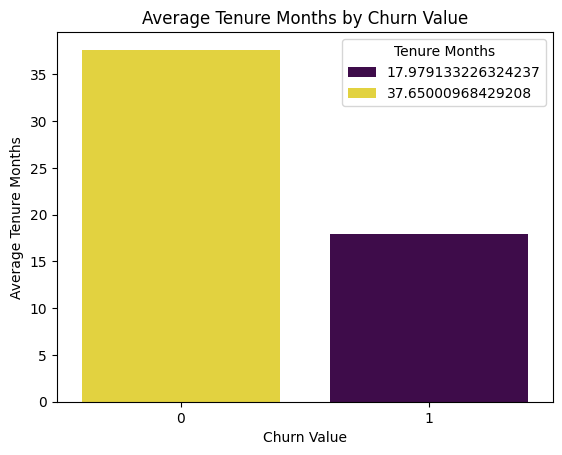

In [38]:
# contract vs churn

sns.countplot(x="Contract", hue="Churn Value", data=df)
plt.title("Contract Type vs Churn Value")
plt.show()


# internet service vs churn

sns.countplot(x="Internet Service", hue="Churn Value", data=df)
plt.title("Internet Service vs Churn Value")
plt.show()


# payment method vs churn

sns.countplot(x="Payment Method", hue="Churn Value", data=df)
plt.title("Payment Method vs Churn Value")
plt.xticks(rotation=45)
plt.show()


# tenure vs churn (mean values)

tenure_churn = df.groupby("Churn Value")["Tenure Months"].mean().reset_index()
sns.barplot(x="Churn Value", y="Tenure Months", data=tenure_churn, palette="viridis", hue="Tenure Months")
plt.title("Average Tenure Months by Churn Value")
plt.xlabel("Churn Value")
plt.ylabel("Average Tenure Months")
plt.show()